## Preamble

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

from cpymad.madx import Madx

# Comment out the following lines if plotting cells give an error
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)
from plot_settings import setPlotSettings
setPlotSettings(font=True)

## Case 1 -- no periodic B.C.

In [2]:
fodo_straight_file0 = """
!====================================================
! FODO cell with no dipoles
! Authors: Todd Satogata, Steve Peggs
! Last edit: March 2, 2024
!====================================================

! Define specie, TOTAL energy [GeV], and log file name
BEAM, particle=proton, energy=275.0;
OPTIOIN, echo;

! Title for plots
TITLE, 'Straight fodo cell';

! Magnet definitions
DRI: DRIFT,  L = 1.0;                    ! [m]
QFH: QUADRUPOLE, L = 0.5, K1 =  0.19;    ! HALF length quadrupole F
QDH: QUADRUPOLE, L = 0.5, K1 = -0.20;    ! HALF length quadrupole D

! Define a 12 m long straight fodo cell, starting at a QF center
fodo_cell_straight: LINE = (QFH, 5*DRI, QDH,QDH, 5*DRI, QFH);

!==================================================================
!! Propagate Twiss parameters from specific initial beta values

USE, SEQUENCE = fodo_cell_straight;  ! Use this beamline with ..
TWISS, BETX = 15.0, BETY = 5.0;      ! .. these initial values
PLOT, HAXIS=S,VAXIS=BETX, BETY, COLOUR=100, file = fodo_straight;

VALUE, TABLE(SUMM,Q1);               ! Write Q1 to madx.log 
WRITE, TABLE=SUMM, FILE = fodo_straight.dat;  ! Very wide !

stop;

COMMENTS: .........................................................
0) Including a "stop;" sign enables commentary like this.
1) Usage: "madx fodo_straight.madx"
2) White space doesn't matter.
3) UPPER and lower case are irrelevant.
4) Don't forget the end-of-line semi-colons ";" !
5) ! or // can be used before comments
"""

In [ ]:
madx = Madx()
madx.input(fodo_straight_file0)
twiss = madx.table.twiss


  ++++++++++++++++++++++++++++++++++++++++++++
  +     MAD-X 5.09.03  (64 bit, Darwin)      +
  + Support: mad@cern.ch, http://cern.ch/mad +
  + Release   date: 2024.04.25               +
  + Execution date: 2026.02.02 15:15:58      +
  ++++++++++++++++++++++++++++++++++++++++++++
++++++ warning: skipped, command or element unknown: optioin
enter Twiss module
  
open line - error with deltap:   0.000000E+00
initial orbit vector:   0.000000E+00  0.000000E+00  0.000000E+00  0.000000E+00  0.000000E+00  0.000000E+00
final orbit vector:     0.000000E+00  0.000000E+00  0.000000E+00  0.000000E+00  0.000000E+00  0.000000E+00

++++++ table: summ

            length             orbit5               alfa            gammatr 
                12                 -0                  0                  0 

                q1                dq1            betxmax              dxmax 
      0.1942588753                  0        25.95361393                  0 

             dxrms             xcomax      

True

### Beta function

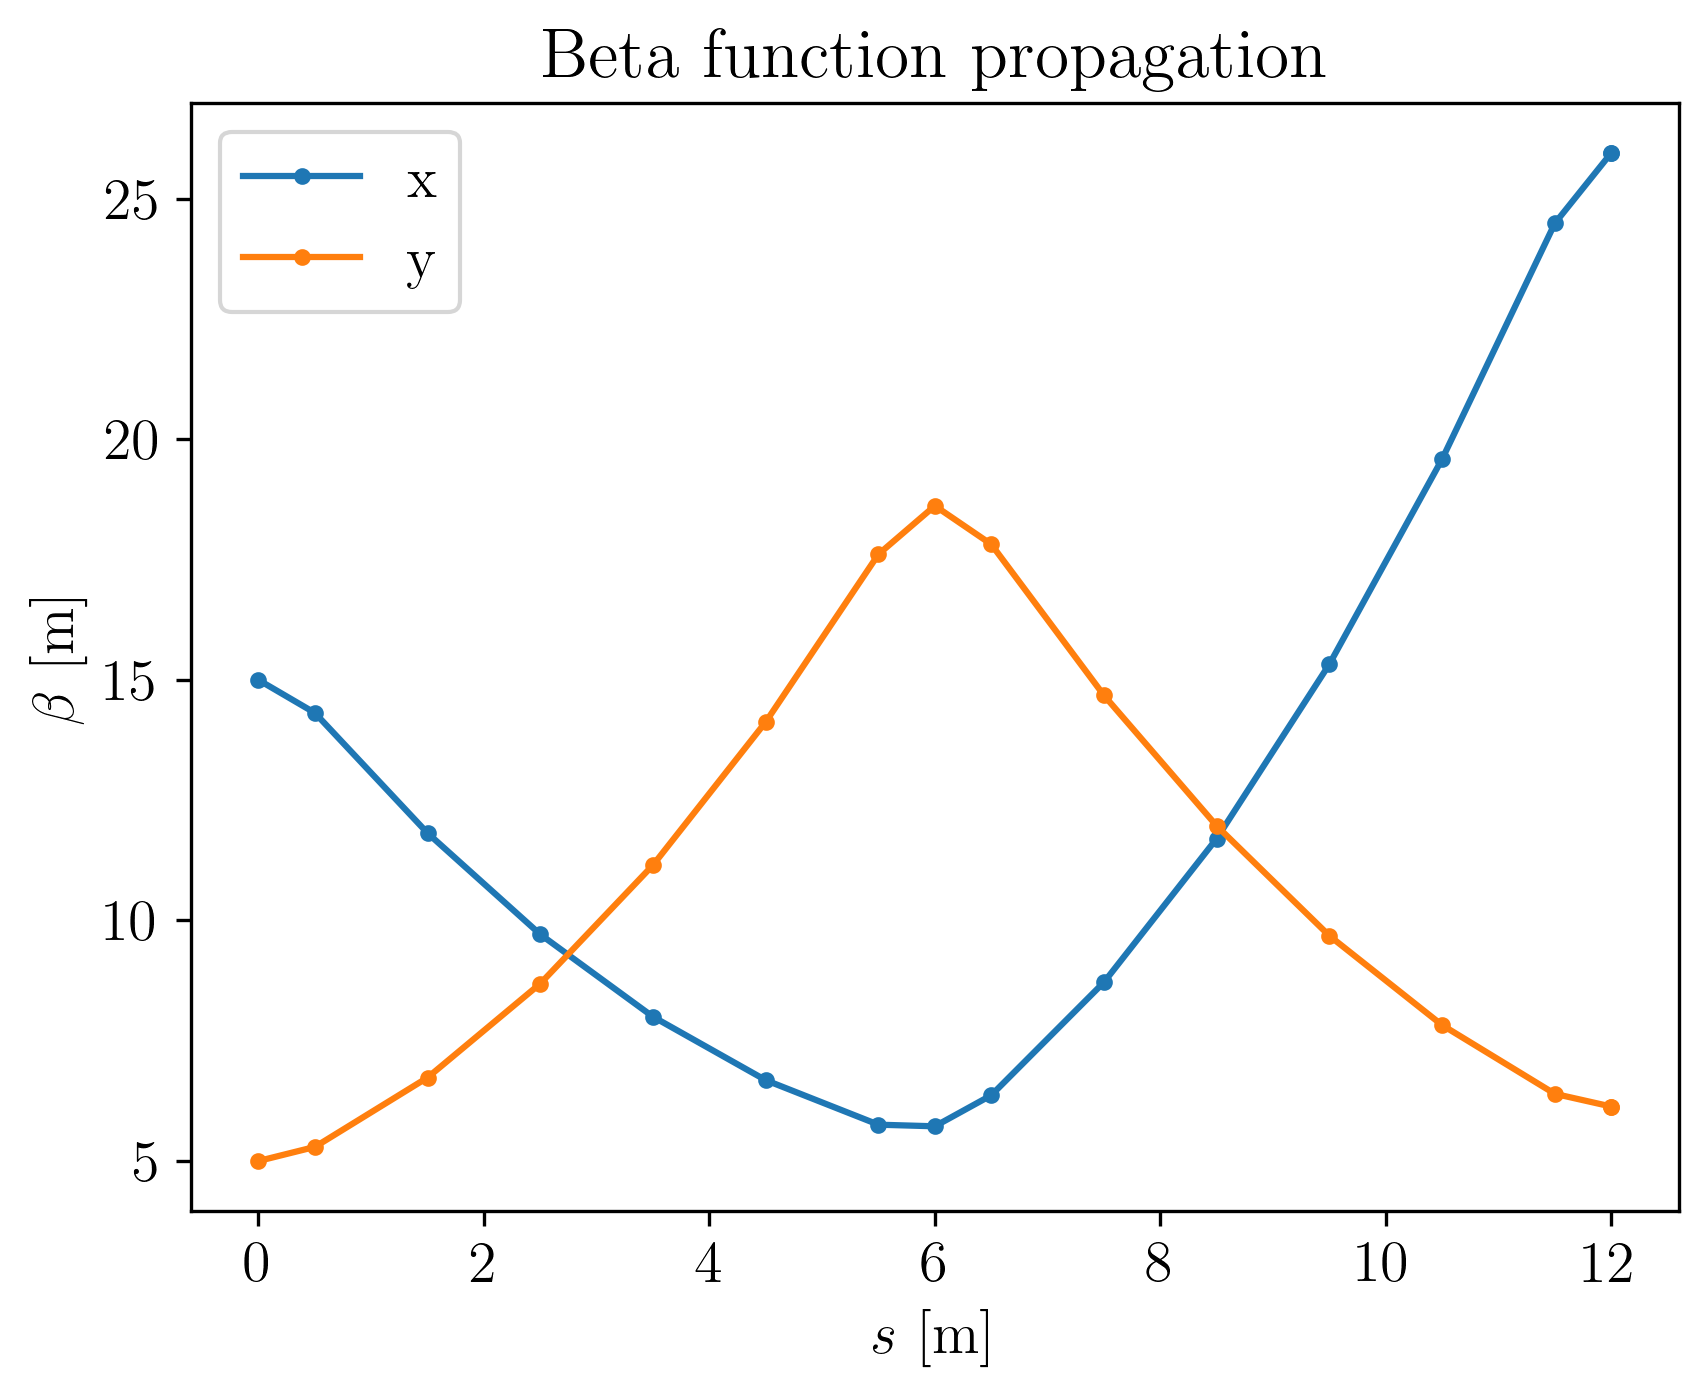

In [5]:
plt.title('Beta function propagation')
plt.plot(twiss.s,twiss.betx,'.-',label='x')
plt.plot(twiss.s,twiss.bety,'.-',label='y')
plt.ylabel(r'$\beta$ [m]')
plt.xlabel('$s$ [m]')
plt.legend()
plt.show()

In [6]:
print(r'Final beta_x:')
print(twiss.betx[len(twiss.betx)-1])

print(r'Final beta_y:')
print(twiss.bety[len(twiss.bety)-1])

Final beta_x:
25.9536139267805
Final beta_y:
6.132134713718153


### Observations

- Changing the initial beta values changes the values at the end of the channel because we have not applied periodic B.C. conditions (i.e. no matching).

- The dispersion is zero because we have not used any dipoles.

- Many other parameters are also zero (e.g. the momentum compaction, orbit deviation, delta p, etc.), which I suspect is because we have not supplied a momentum distribution. These are not (purely) properties of the lattice.

## Case 2 -- w/ periodic B.C.

In [7]:
fodo_straight_file_bound = """
! Define specie, TOTAL energy [GeV], and log file name
BEAM, particle=proton, energy=275.0;
OPTIOIN, echo;

! Title for plots
TITLE, 'Straight fodo cell';

! Magnet definitions
DRI: DRIFT,  L = 1.0;                    ! [m]
QFH: QUADRUPOLE, L = 0.5, K1 =  0.19;    ! HALF length quadrupole F
QDH: QUADRUPOLE, L = 0.5, K1 = -0.20;    ! HALF length quadrupole D

! Define a 12 m long straight fodo cell, starting at a QF center
fodo_cell_straight: LINE = (QFH, 5*DRI, QDH,QDH, 5*DRI, QFH);

USE, SEQUENCE = fodo_cell_straight;  ! Use this beamline with ..

!==================================================================
!! Propagate Twiss functions with Periodic Boundary Conditions

MATCH, SEQUENCE = fodo_cell_straight;
TWISS, save;
PLOT, HAXIS=S, VAXIS=BETX, BETY, COLOUR=100;

stop;
"""

In [8]:
madx_bound = Madx()
madx_bound.input(fodo_straight_file_bound)
twiss_bound = madx_bound.table.twiss


  ++++++++++++++++++++++++++++++++++++++++++++
  +     MAD-X 5.09.03  (64 bit, Darwin)      +
  + Support: mad@cern.ch, http://cern.ch/mad +
  + Release   date: 2024.04.25               +
  + Execution date: 2026.02.02 15:15:59      +
  ++++++++++++++++++++++++++++++++++++++++++++
++++++ warning: skipped, command or element unknown: optioin
START MATCHING

number of sequences: 1
sequence name: fodo_cell_straight
Plot - default table plotted: twiss

 GXPLOT-X11  1.50 initialized

 plot number =            1

  Number of warnings: 1
1 in C and 0 in Fortran

  ++++++++++++++++++++++++++++++++++++++++++++
  +          MAD-X finished normally         +
  ++++++++++++++++++++++++++++++++++++++++++++


### Beta function

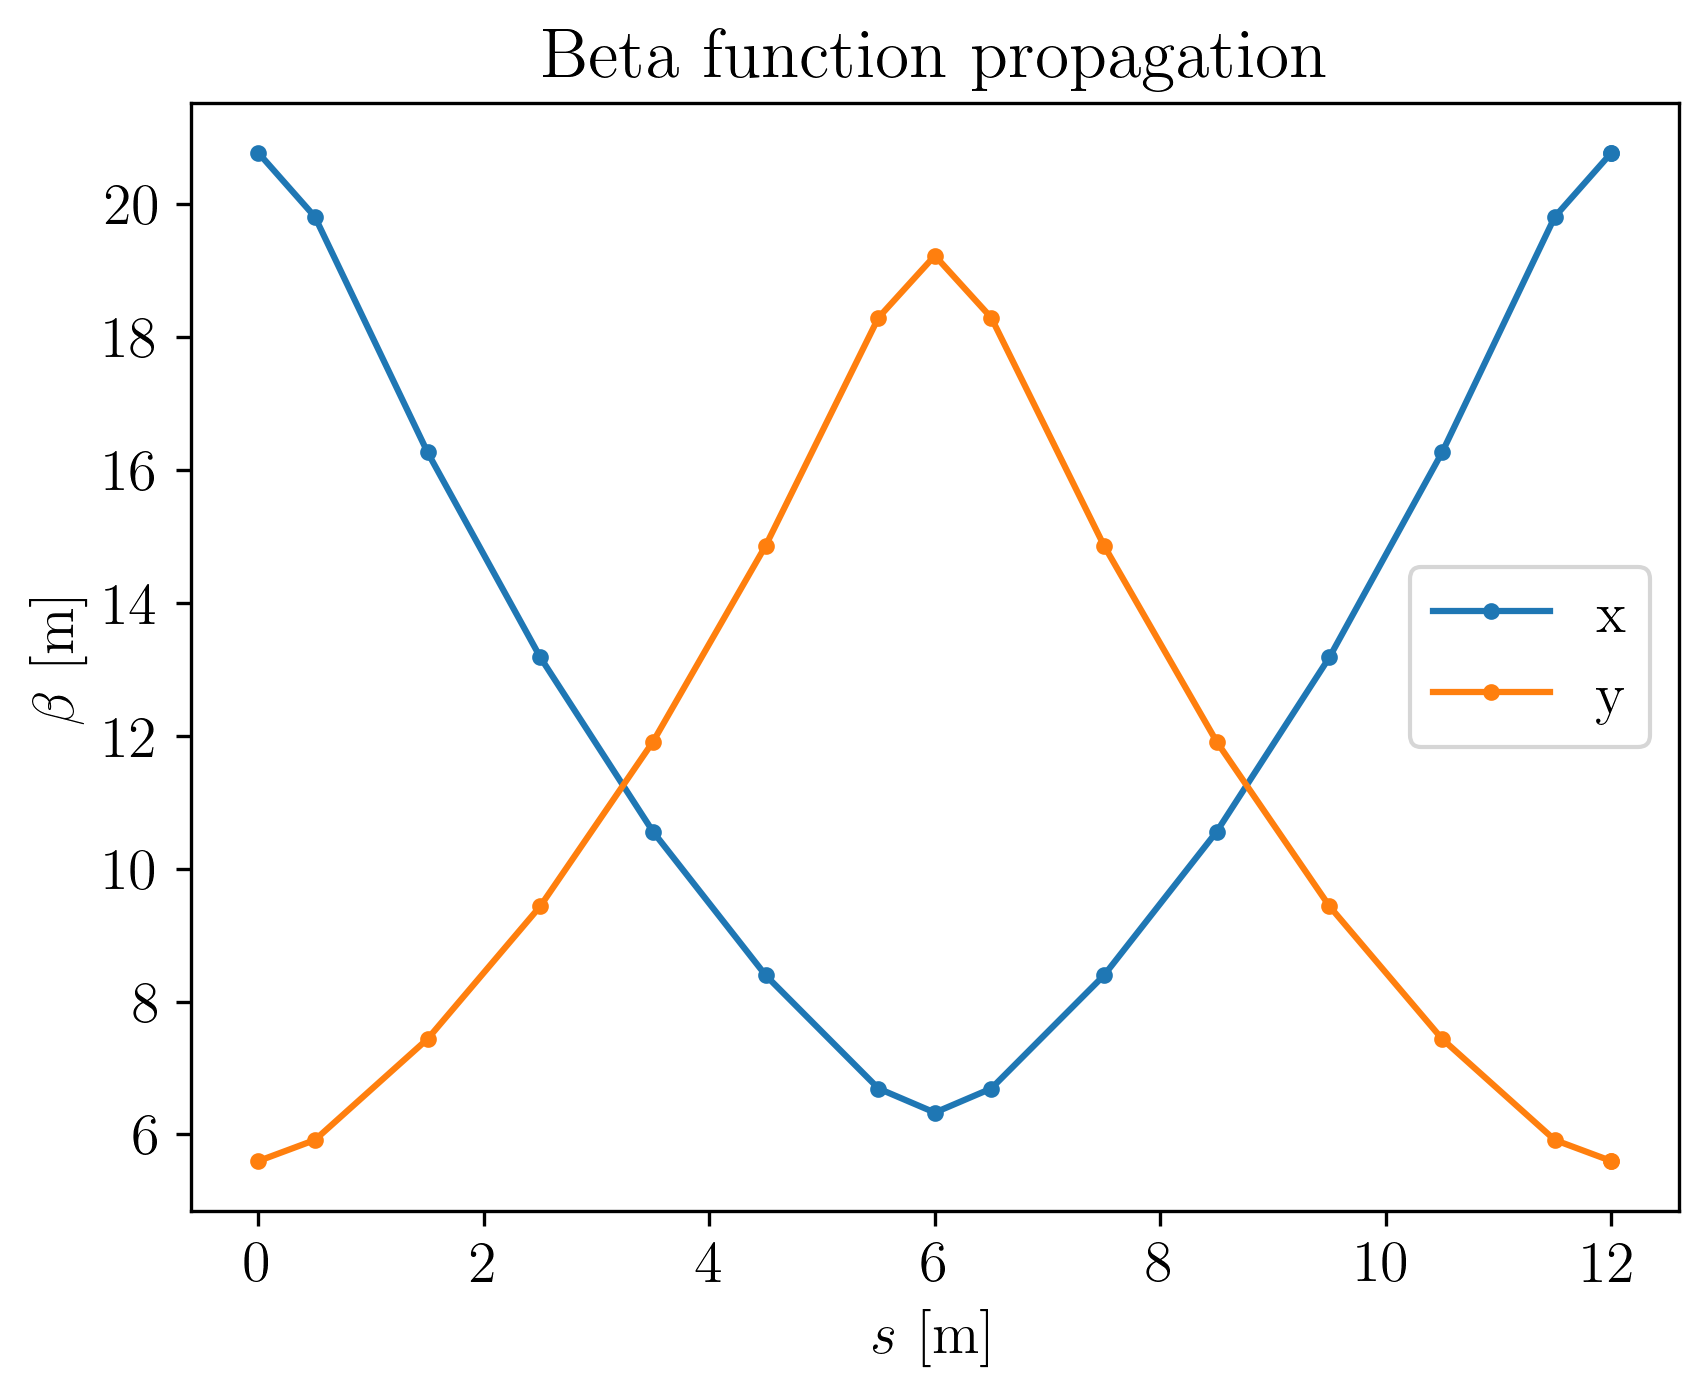

In [9]:
plt.title('Beta function propagation')
plt.plot(twiss_bound.s,twiss_bound.betx,'.-',label='x')
plt.plot(twiss_bound.s,twiss_bound.bety,'.-',label='y')
plt.ylabel(r'$\beta$ [m]')
plt.xlabel('$s$ [m]')
plt.legend()
plt.show()

In [10]:
print(r'Final beta_x:')
print(twiss_bound.betx[len(twiss_bound.betx)-1])

print(r'Final beta_y:')
print(twiss_bound.bety[len(twiss_bound.bety)-1])

Final beta_x:
20.768584886883264
Final beta_y:
5.6007270008040875


In [11]:
print(r'Max beta_x:')
print(np.max(twiss_bound.betx))

print(r'Max beta_y:')
print(np.max(twiss_bound.bety))

Max beta_x:
20.768584886883264
Max beta_y:
19.223814879201235


In [12]:
print(r'Min beta_x:')
print(np.min(twiss_bound.betx))

print(r'Min beta_y:')
print(np.min(twiss_bound.bety))

Min beta_x:
6.329089580463702
Min beta_y:
5.6007270008040875


### Phase advance

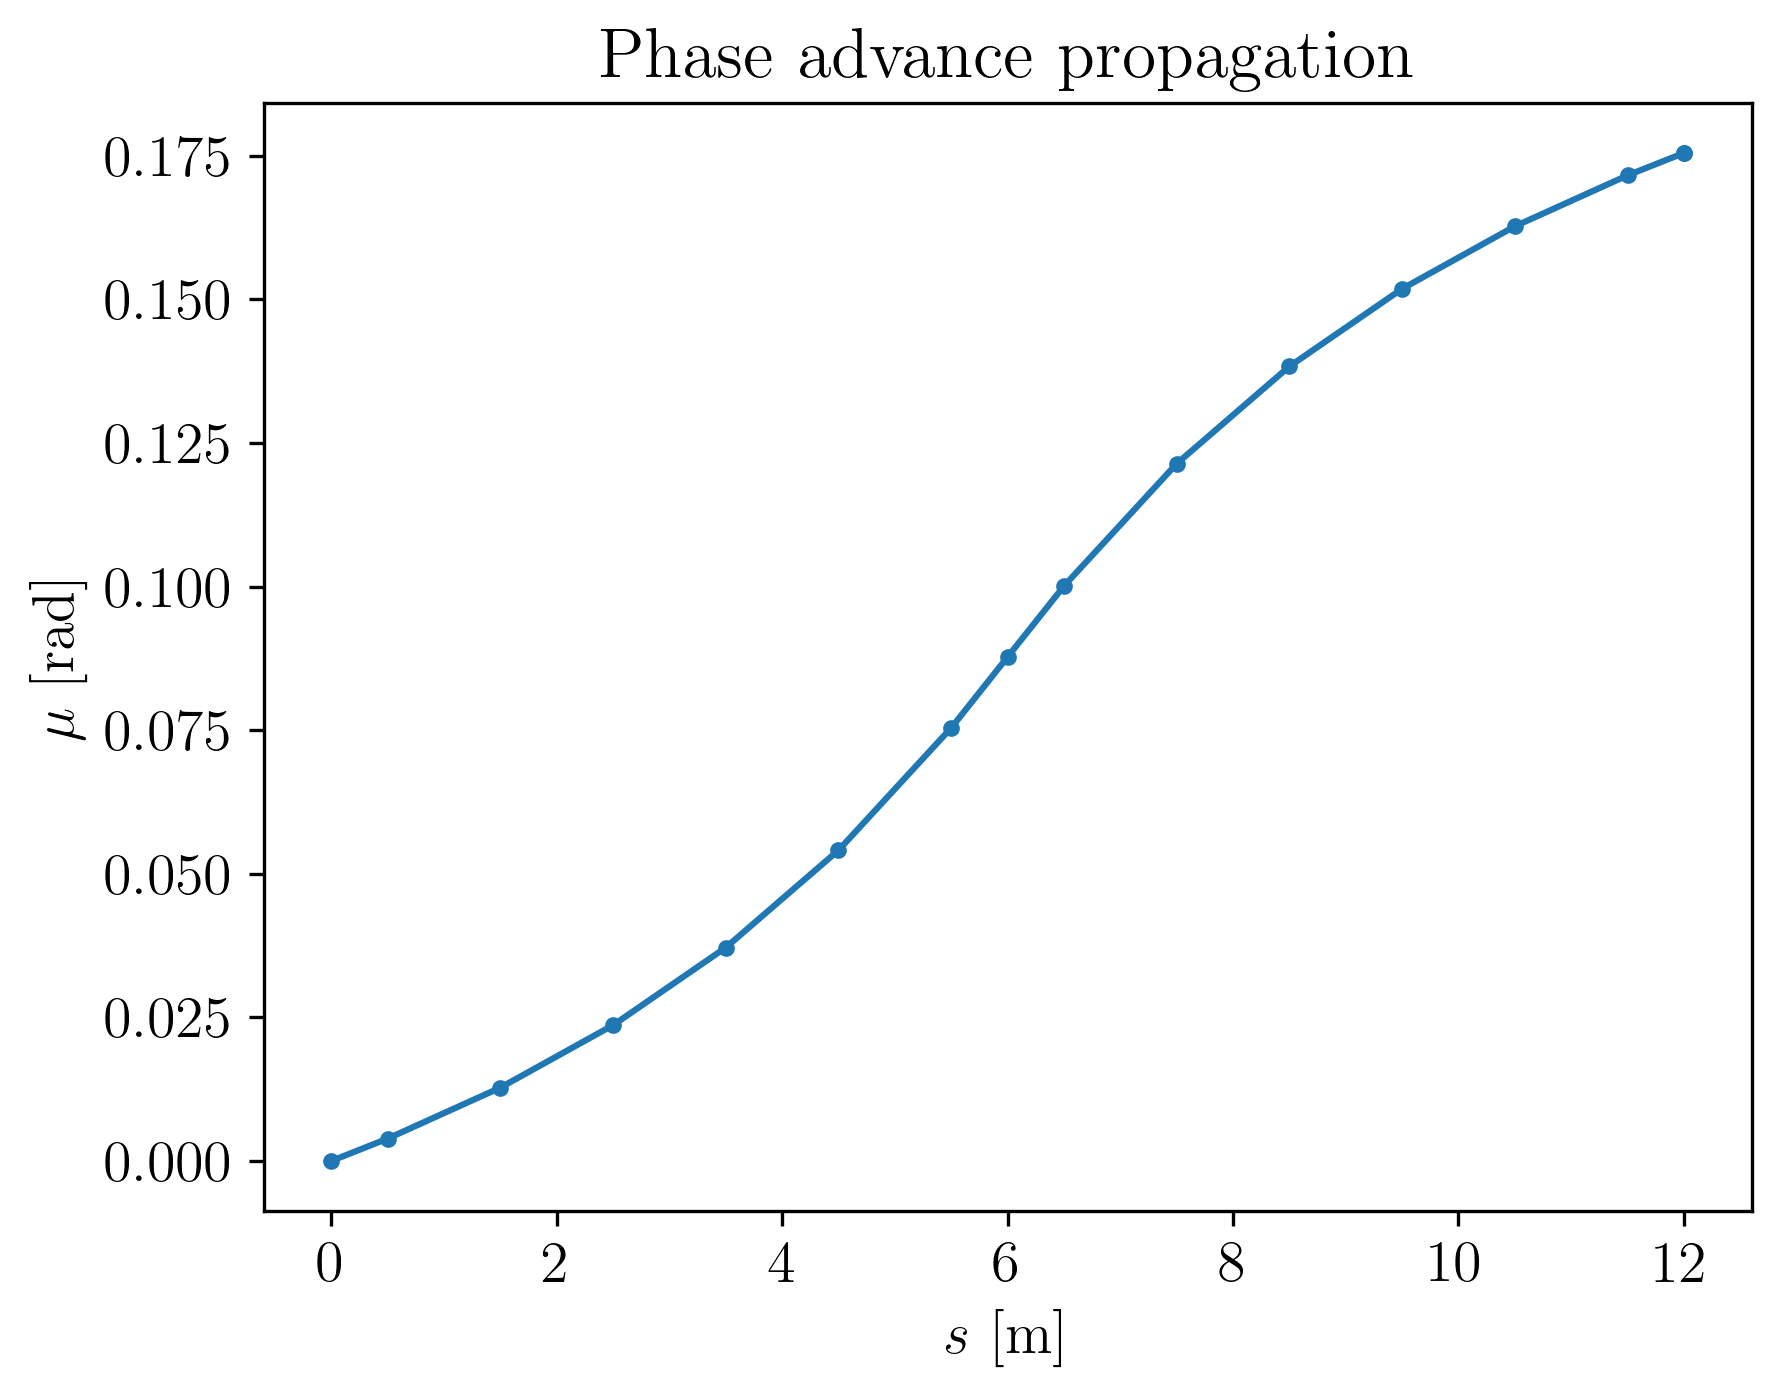

In [13]:
plt.title('Phase advance propagation')
plt.plot(twiss_bound.s,twiss_bound.mux,'.-')
plt.ylabel(r'$\mu$ [rad]')
plt.xlabel('$s$ [m]')
plt.show()

### Observations

- Now that matching is enabled (i.e. periodic B.C. are enforced), adjusting the initial beta values has no effect on the final values.

## Case 3 -- beta_x and beta_y equivalent

In [14]:
fodo_straight_file_bound2 = """
! Define specie, TOTAL energy [GeV], and log file name
BEAM, particle=proton, energy=275.0;
OPTIOIN, echo;

! Title for plots
TITLE, 'Straight fodo cell';

! Magnet definitions
DRI: DRIFT,  L = 1.0;                    ! [m]
QFH: QUADRUPOLE, L = 0.5, K1 =  0.20;    ! HALF length quadrupole F
QDH: QUADRUPOLE, L = 0.5, K1 = -0.20;    ! HALF length quadrupole D

! Define a 12 m long straight fodo cell, starting at a QF center
fodo_cell_straight: LINE = (QFH, 5*DRI, QDH,QDH, 5*DRI, QFH);

USE, SEQUENCE = fodo_cell_straight;  ! Use this beamline with ..

!==================================================================
!! Propagate Twiss functions with Periodic Boundary Conditions

MATCH, SEQUENCE = fodo_cell_straight;
TWISS, save;
PLOT, HAXIS=S, VAXIS=BETX, BETY, COLOUR=100;

stop;
"""

In [15]:
madx_bound2 = Madx()
madx_bound2.input(fodo_straight_file_bound2)
twiss_bound2 = madx_bound2.table.twiss


  ++++++++++++++++++++++++++++++++++++++++++++
  +     MAD-X 5.09.03  (64 bit, Darwin)      +
  + Support: mad@cern.ch, http://cern.ch/mad +
  + Release   date: 2024.04.25               +
  + Execution date: 2026.02.02 15:15:59      +
  ++++++++++++++++++++++++++++++++++++++++++++
++++++ warning: skipped, command or element unknown: optioin
START MATCHING

number of sequences: 1
sequence name: fodo_cell_straight
Plot - default table plotted: twiss

 GXPLOT-X11  1.50 initialized

 plot number =            1

  Number of warnings: 1
1 in C and 0 in Fortran

  ++++++++++++++++++++++++++++++++++++++++++++
  +          MAD-X finished normally         +
  ++++++++++++++++++++++++++++++++++++++++++++


In [16]:
print(r'Max beta_x:')
print(np.max(twiss_bound2.betx))

print(r'Max beta_y:')
print(np.max(twiss_bound2.bety))

Max beta_x:
19.818489282044897
Max beta_y:
19.8184892820449


Setting both quads to $|k1| = 0.20$ $\implies$ $\beta_{max,x} = \beta_{max,y}$

### Beta_max from theory

Equation 3.50:
$$ \frac{\beta_{max}}{L} = \frac{1+\sin{(\Delta\phi/2)}}{{\sin{(\Delta{\phi}/2)}\cos{(\Delta{\phi}/2)} }} $$
$$ \implies \beta_{max} = \frac{L(1+\sin{(\Delta\phi/2)})}{{\sin{(\Delta{\phi}/2)}\cos{(\Delta{\phi}/2)} }} $$
where $L$ is half the length of the FODO cell.

In [17]:
print('Horizontal tune:')
q1 = madx_bound2.table.summ.q1[0]
print(q1)
print('Vertical tune:')
q2 = madx_bound2.table.summ.q2[0]
print(q2)
print('(same for x and y)')

Horizontal tune:
0.19134599315627437
Vertical tune:
0.19134599315627437
(same for x and y)


In [18]:
dphi = 2*pi*q1
s = np.sin(dphi/2)
c = np.cos(dphi/2)
L = 6
betamax = L*(1+s)/(s*c)
print('Beta_max:')
print(betamax)

Beta_max:
20.139119973142286


In [19]:
print(np.abs((np.max(twiss_bound.betx)-betamax)/np.max(twiss_bound.betx)))

0.030308512456162923


### Observations

- The horizontal and vertical $\beta_{max}$ were initially not equivalent. They were made equal by setting the magnitude of the quadrupole strengths to be the same s.t. there is equal focusing along both transverse axes. 

- The values obtained from the tune and Equation 3.50 are quite close to the MADX values (~3\% discrepancy).

## Case 4 -- increased drift length

In [20]:
Ldrift_vals = np.arange(1.0,1.9,0.1)

In [21]:
Bmax_vals = []
for L in Ldrift_vals:

    fodo_straight_file_bound3 = f"""
    ! Define specie, TOTAL energy [GeV], and log file name
    BEAM, particle=proton, energy=275.0;
    OPTIOIN, echo;

    ! Title for plots
    TITLE, 'Straight fodo cell';

    ! Magnet definitions
    DRI: DRIFT,  L = {L};                    ! [m]
    QFH: QUADRUPOLE, L = 0.5, K1 =  0.20;    ! HALF length quadrupole F
    QDH: QUADRUPOLE, L = 0.5, K1 = -0.20;    ! HALF length quadrupole D

    ! Define a 12 m long straight fodo cell, starting at a QF center
    fodo_cell_straight: LINE = (QFH, 5*DRI, QDH,QDH, 5*DRI, QFH);

    USE, SEQUENCE = fodo_cell_straight;  ! Use this beamline with ..

    !==================================================================
    !! Propagate Twiss functions with Periodic Boundary Conditions

    MATCH, SEQUENCE = fodo_cell_straight;
    TWISS, save;
    PLOT, HAXIS=S, VAXIS=BETX, BETY, COLOUR=100;

    stop;
    """
    madx_bound3 = Madx(stdout=False)
    madx_bound3.input(fodo_straight_file_bound3)

    twiss_bound3 = madx_bound3.table.twiss

    Bmax_vals.append(np.max(twiss_bound3.betx))

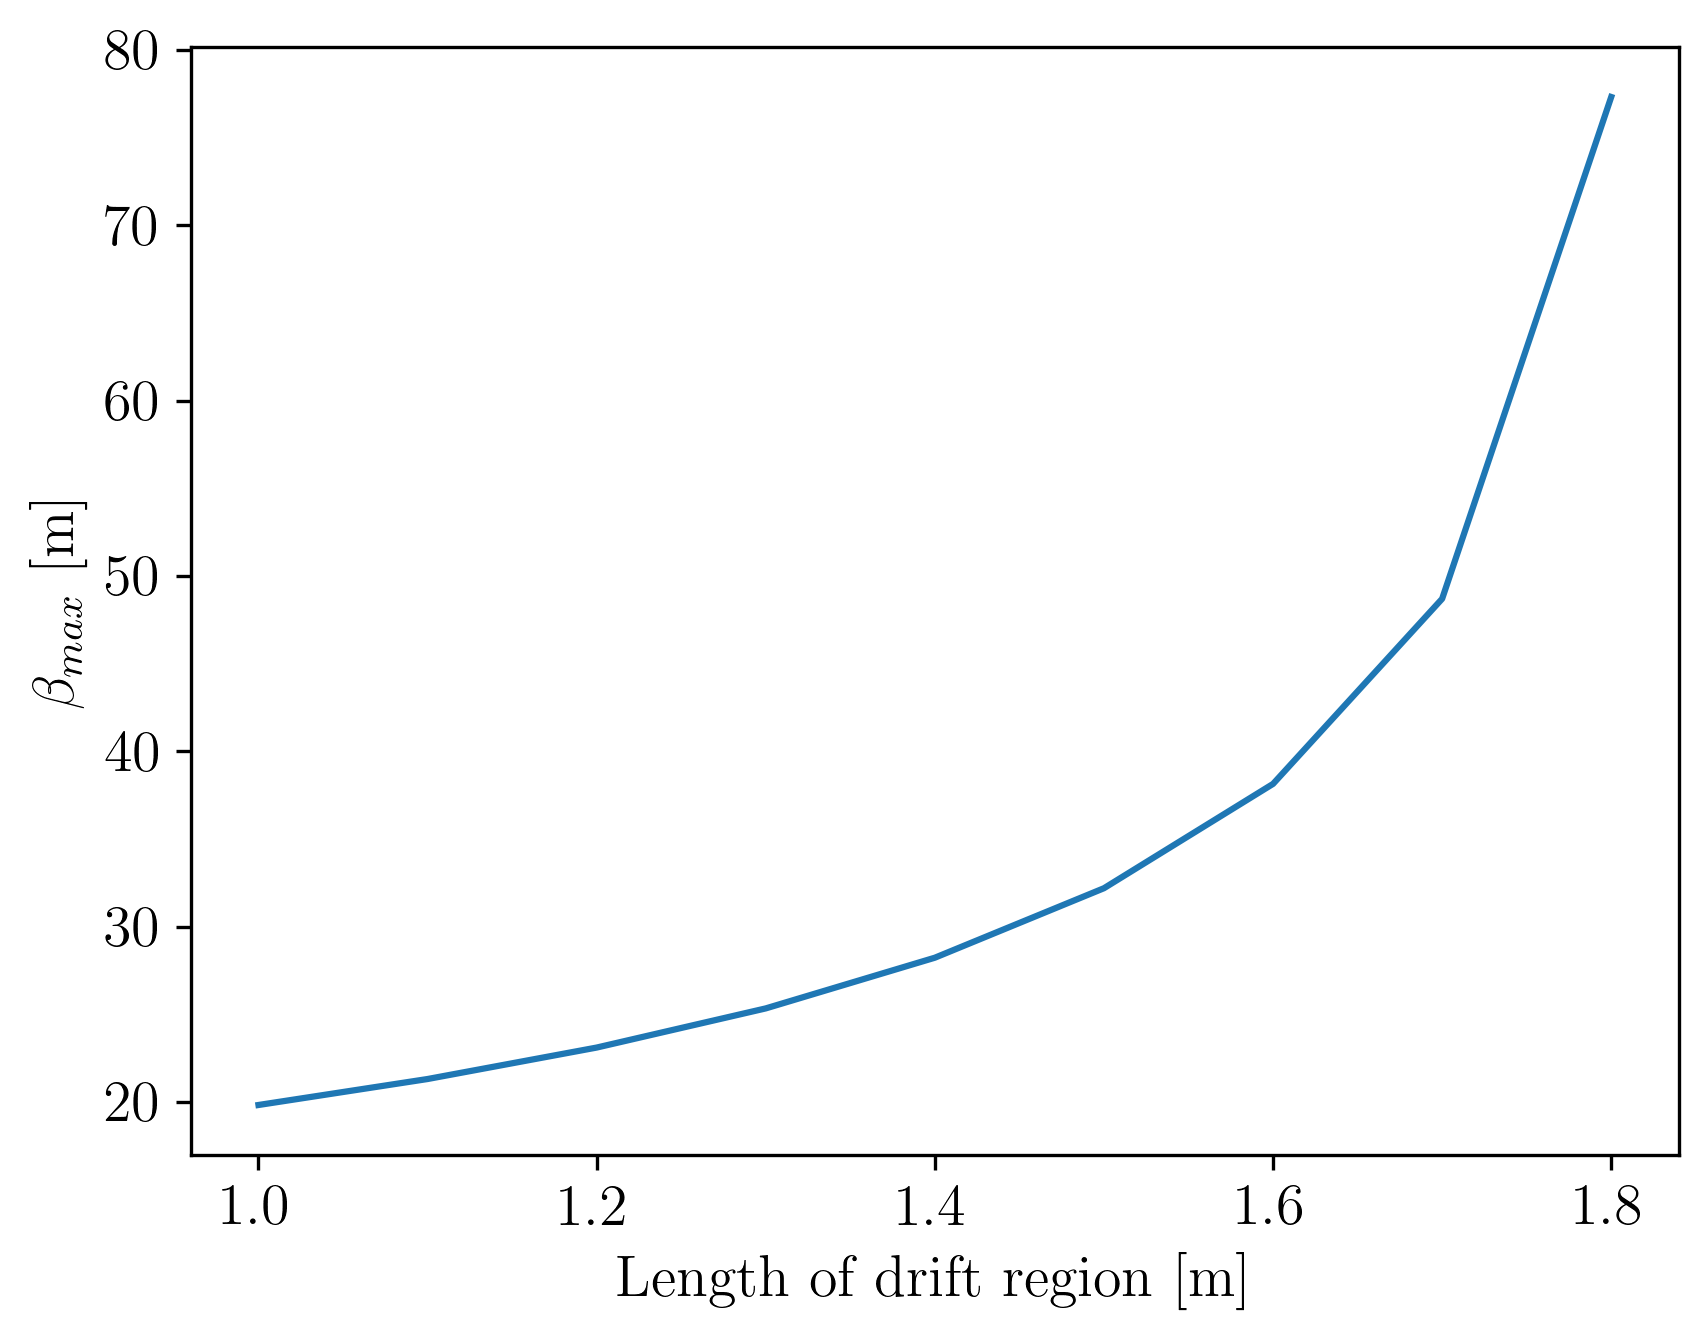

In [22]:
plt.plot(Ldrift_vals,Bmax_vals)
plt.xlabel('Length of drift region [m]')
plt.ylabel(r'$\beta_{max}$ [m]')
plt.show()

Let us try to figure out why we see this behavior.

Equation 3.47:

$$ M_{FODO} = \left( \begin{matrix} 1-2(qL)^2 & 2L(1+qL) \\ -2q(qL)(1-qL) & 1-2(qL)^2  \end{matrix} \right) = \left( \begin{matrix} C+\alpha S & \beta S \\ -\gamma S & C-\alpha S \end{matrix} \right) $$

$$ \implies \beta(L) = \frac{2}{S}(qL^2+L) $$

where $L$ is the length of the drift region.

In [23]:
############## fit to see if the data does indeed agree with this function ##############

In [1]:
############## animate Twiss params vs. s as drift region is extended ##############

### Observations

- $\beta_{max} \propto qL^2+L$ where $L$ is the drift length.

- Setting the length of the drift region to $\boxed{1.9\text{m}}$ (or thereabout) causes an error because of the diverging beta value. $\implies$ The cell length is too long at that value.

## v. 5 -- double cell length, half quad strength

In order to double the overall length of the cell (while maintaining the length of the magnets), we will need 22 of the 1 m drift regions in total instead of 10.

In [24]:
fodo_straight_file_bound4 = """
! Define specie, TOTAL energy [GeV], and log file name
BEAM, particle=proton, energy=275.0;
OPTIOIN, echo;

! Title for plots
TITLE, 'Straight fodo cell';

! Magnet definitions
DRI: DRIFT,  L = 1.0;                    ! [m]
QFH: QUADRUPOLE, L = 0.5, K1 =  0.10;    ! HALF length quadrupole F
QDH: QUADRUPOLE, L = 0.5, K1 = -0.10;    ! HALF length quadrupole D

! Define a 12 m long straight fodo cell, starting at a QF center
fodo_cell_straight: LINE = (QFH, 11*DRI, QDH,QDH, 11*DRI, QFH);

USE, SEQUENCE = fodo_cell_straight;  ! Use this beamline with ..

!==================================================================
!! Propagate Twiss functions with Periodic Boundary Conditions

MATCH, SEQUENCE = fodo_cell_straight;
TWISS, save;
PLOT, HAXIS=S, VAXIS=BETX, BETY, COLOUR=100;

stop;
"""

In [25]:
madx_bound4 = Madx()
madx_bound4.input(fodo_straight_file_bound4)


  ++++++++++++++++++++++++++++++++++++++++++++
  +     MAD-X 5.09.03  (64 bit, Darwin)      +
  + Support: mad@cern.ch, http://cern.ch/mad +
  + Release   date: 2024.04.25               +
  + Execution date: 2026.02.02 15:16:00      +
  ++++++++++++++++++++++++++++++++++++++++++++
++++++ warning: skipped, command or element unknown: optioin
START MATCHING

number of sequences: 1
sequence name: fodo_cell_straight
Plot - default table plotted: twiss

 GXPLOT-X11  1.50 initialized

 plot number =            1

  Number of warnings: 1
1 in C and 0 in Fortran

  ++++++++++++++++++++++++++++++++++++++++++++
  +          MAD-X finished normally         +
  ++++++++++++++++++++++++++++++++++++++++++++


True

In [26]:
twiss_bound4 = madx_bound4.table.twiss

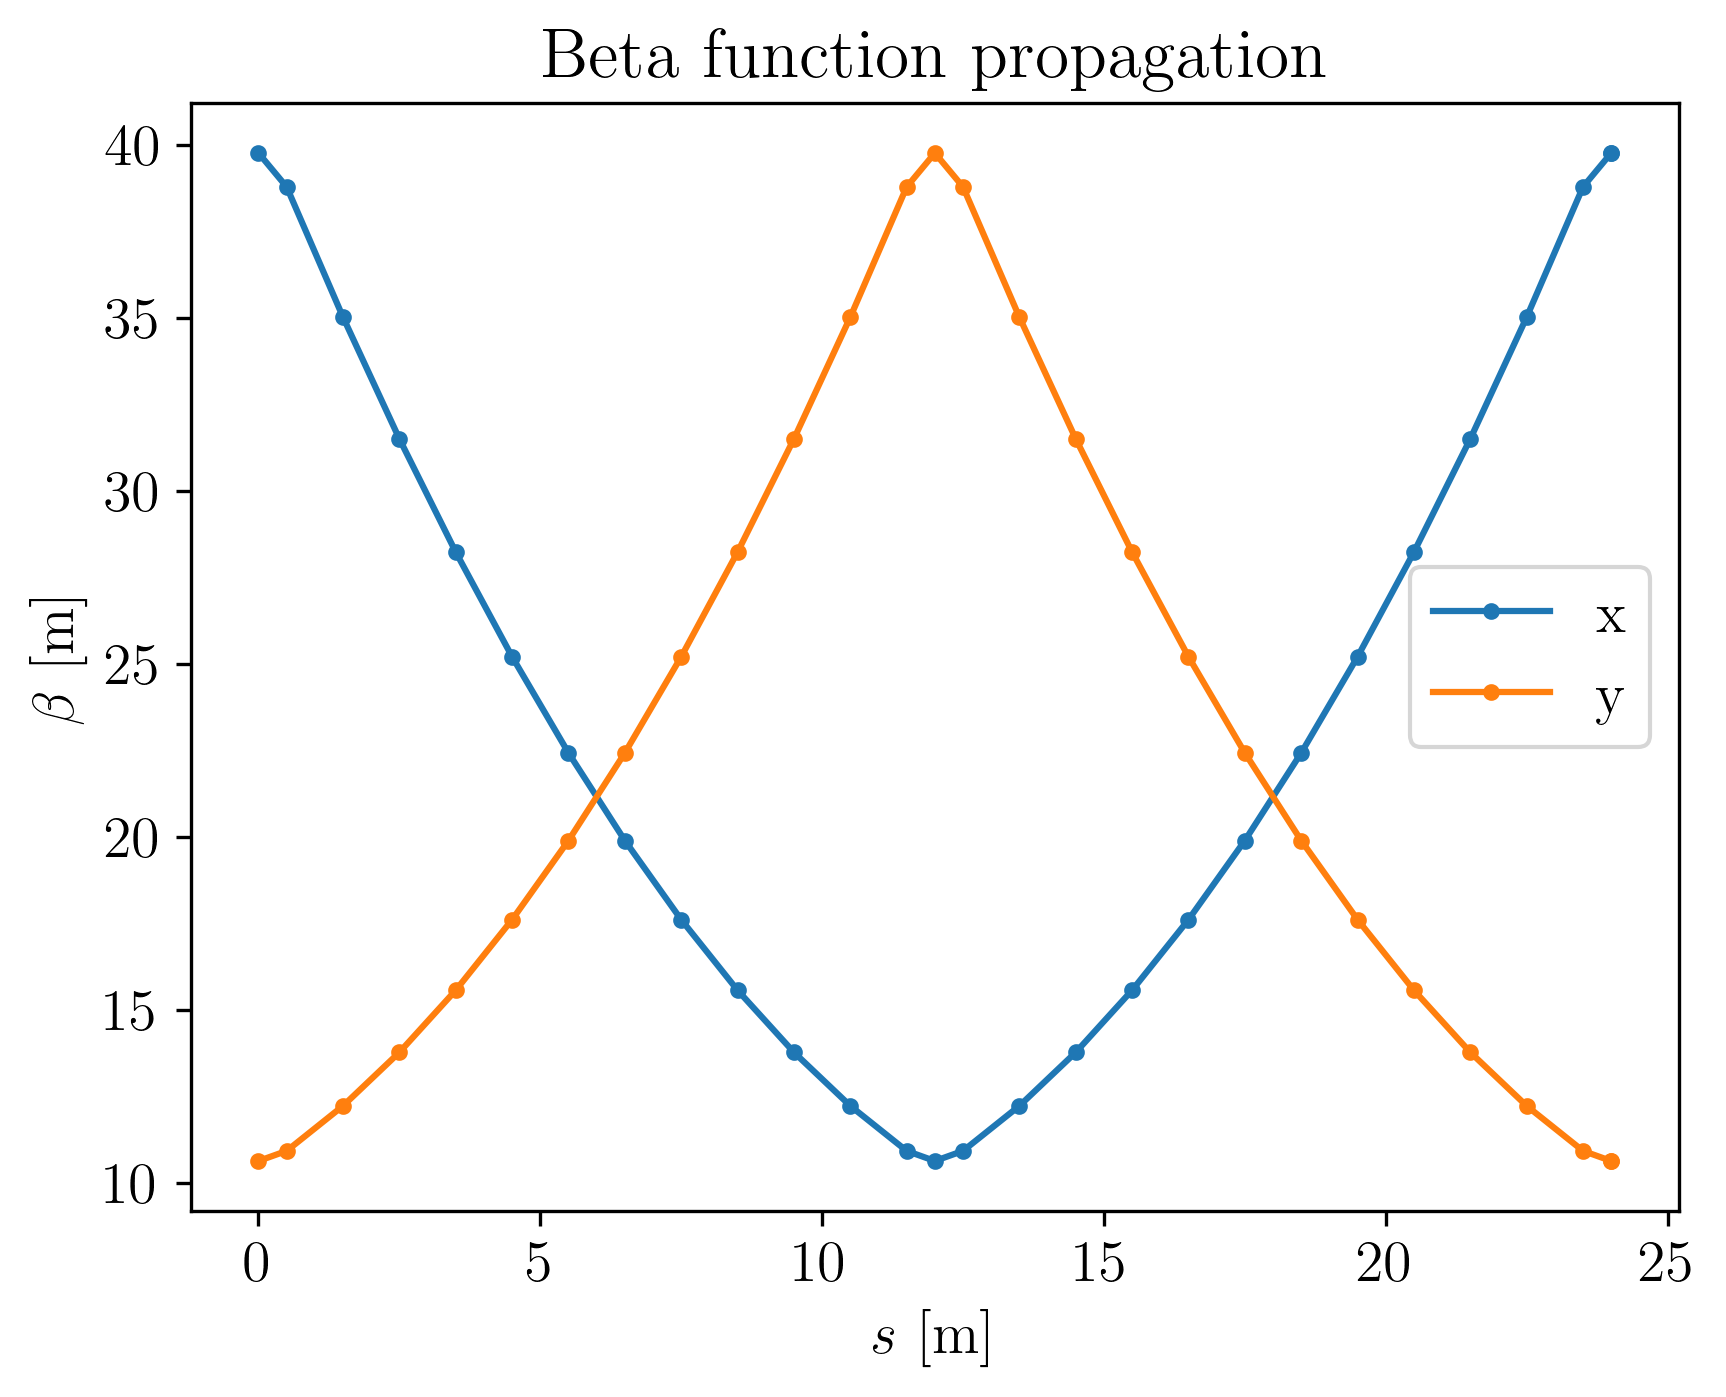

In [27]:
plt.title('Beta function propagation')
plt.plot(twiss_bound4.s,twiss_bound4.betx,'.-',label='x')
plt.plot(twiss_bound4.s,twiss_bound4.bety,'.-',label='y')
plt.ylabel(r'$\beta$ [m]')
plt.xlabel('$s$ [m]')
plt.legend()
plt.show()

In [28]:
print(r'Max beta_x:')
print(np.max(twiss_bound4.betx))

print(r'Max beta_y:')
print(np.max(twiss_bound4.bety))

Max beta_x:
39.77602916684436
Max beta_y:
39.77602916684435


In [29]:
# w/ original lattice params:

print(r'Max beta_x:')
print(np.max(twiss_bound2.betx))

print(r'Max beta_y:')
print(np.max(twiss_bound2.bety))

Max beta_x:
19.818489282044897
Max beta_y:
19.8184892820449


In [ ]:
############## write an interpretation of these results ##############